In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
df = pd.read_csv(url)
columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[columns]

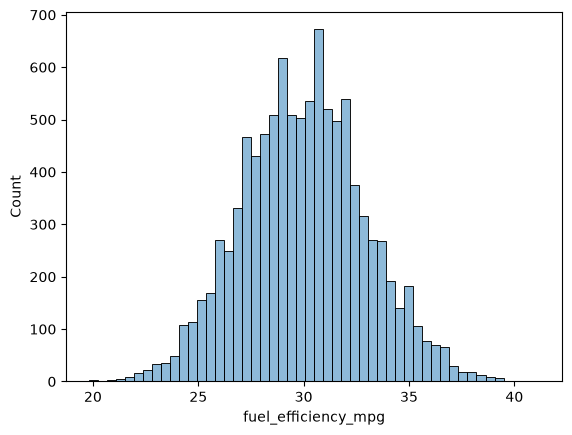

In [39]:

sns.histplot(df['fuel_efficiency_mpg'], kde=False, alpha = 0.5, bins=50)
plt.show()

Summary. the distribution of fuel_efficiency_mpg is close to symmetric and doesnt have a long tail. Data confirm it: 
1. Skewness is close to 0. 2
2. Mean and median are almost coincide
3. the histogram looks like a bell-shape

In [40]:
print(df['fuel_efficiency_mpg'].describe())

skewness = df['fuel_efficiency_mpg'].skew()

print("Skewness of 'fuel_efficiency_mpg':", skewness)


count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64
Skewness of 'fuel_efficiency_mpg': 0.08080419601878173


Q1. There's one column with missing values. What is it?

In [41]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Q2. What's the median (50% percentile) for variable 'horsepower'? 

In [42]:


df['horsepower'].median()

np.float64(254.0)

Q3. Which option gives better RMSE?

In [43]:
df = df.copy()

def split_data(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    y_train = df_train.pop('fuel_efficiency_mpg').values
    y_val = df_val.pop('fuel_efficiency_mpg').values
    y_test = df_test.pop('fuel_efficiency_mpg').values

    return df_train, df_val, df_test, y_train, y_val, y_test


def train_linear_regression(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())


def prepare_X(df, fill_value):
    return df.fillna(fill_value).values



In [44]:
df_train, df_val, df_test, y_train, y_val, y_test = split_data(df, 42)

w0, w = train_linear_regression(prepare_X(df_train, 0), y_train)
y_pred = w0 + prepare_X(df_val, 0).dot(w)
print('With 0:   ', round(rmse(y_val, y_pred), 3))

mean_hp = df_train['horsepower'].mean()
w0, w = train_linear_regression(prepare_X(df_train, mean_hp), y_train)
y_pred = w0 + prepare_X(df_val, mean_hp).dot(w)
print('With mean:', round(rmse(y_val, y_pred), 3))


With 0:    2.205
With mean: 2.202


Q4. Which r gives the best RMSE?

In [45]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression(prepare_X(df_train, 0), y_train, r=r)
    y_pred = w0 + prepare_X(df_val, 0).dot(w)
    print(r, round(rmse(y_val, y_pred), 4))


0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


Q5.

In [46]:
scores = []
for seed in range(10):
    df_tr, df_v, df_te, y_tr, y_v, y_te = split_data(df, seed)
    w0, w = train_linear_regression(prepare_X(df_tr, 0), y_tr)
    y_pred = w0 + prepare_X(df_v, 0).dot(w)
    scores.append(rmse(y_v, y_pred))

print(round(np.std(scores), 3))


0.029


Q6. What's the RMSE on the test dataset?

In [47]:
df_tr, df_v, df_te, y_tr, y_v, y_te = split_data(df, 9)

df_full = pd.concat([df_tr, df_v]).reset_index(drop=True)
y_full = np.concatenate([y_tr, y_v])

w0, w = train_linear_regression(prepare_X(df_full, 0), y_full, r=0.001)
y_pred = w0 + prepare_X(df_te, 0).dot(w)
print(round(rmse(y_te, y_pred), 3))


2.236
